In [3]:
"""
ring_plot.py  –  Kreisförmiger Segment-Vergleichsplot für Interferenzring-Bilder
================================================================================
Jedes Segment zeigt denselben Ausschnitt (zentriert auf den Interferenzring) aus
einem anderen Bild. Rendering mit Matplotlib.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from PIL import Image

# ── ① KONFIGURATION ────────────────────────────────────────────────────────────
middle = [(300, 300) for _ in range(10)]
radius = 230                                  # Ausgabekreis-Radius in Pixeln
                                            # (kein Qualitätsverlust, solange Quellbild groß genug)

paths = [                                   # Pfade zu den Quellbildern
    "1A_green.png", "2A_green.png", "3A_green.png", "4A_green.png", "5A_green.png",
    "6A_green.png", "7A_green.png", "8A_green.png", "9A_green.png", "10A_green.png",
]
labels = [                                  # Labels je Segment (\n für Zeilenumbruch)
    "1A\n95.55mT", "2A\n173.61mT", "3A\n251.67mT", "4A\n329.73mT", "5A\n407.79mT",
    "6A\n485.85mT", "7A\n563.91mT", "8A\n641.97mT", "9A\n720.03mT", "10A\n798.09mT",
]

# ── Überschrift ────────────────────────────────────────────────────────────────
title           = None   # None = keine Überschrift
title_fontsize  = 5                            # Schriftgröße Überschrift
title_pad       = 12                            # Abstand Überschrift → Kreis (pt)

# ── Segment-Labels ─────────────────────────────────────────────────────────────
label_fontsize  = 3                            # Schriftgröße Labels
label_color     = "white"
label_r_frac    = 0.72                          # Radiale Position (0–1)
label_shadow    = True                          # Schwarzer Rand um Text (besser lesbar)
label_shadow_width = 0.5

# ── Trennlinien ────────────────────────────────────────────────────────────────
line_color      = "white"
line_alpha      = 0.85
line_width      = 0.5

# ── Außenrand ──────────────────────────────────────────────────────────────────
border_color    = "black"
border_alpha    = 0.7
border_lw       = 0.5

# ── Ausgabe ────────────────────────────────────────────────────────────────────
start_angle_offset = 0.0       # Drehung des ersten Segments in Grad (0 = oben, CW)
fig_dpi            = 350       # DPI des gespeicherten Bilds
output_path        = "zeemann_longitudinal_annormal.png"

# ── ② BILDER LADEN ─────────────────────────────────────────────────────────────

n = len(paths)
assert len(middle) == n and len(labels) == n, \
    "middle, paths und labels müssen gleich lang sein."

images = []
for p in paths:
    img = Image.open(p).convert("RGB")
    images.append(np.array(img, dtype=np.uint8))

# ── ③ PIXEL-SAMPLING (vektorisiert) ───────────────────────────────────────────

out_size = 2 * radius + 1
ocx = ocy = radius

ys_g, xs_g = np.mgrid[0:out_size, 0:out_size]
dx = xs_g - ocx
dy = ys_g - ocy
dist = np.hypot(dx, dy)

angle_deg = (np.degrees(np.arctan2(dx, -dy)) - start_angle_offset) % 360.0
seg_idx   = (angle_deg / (360.0 / n)).astype(int).clip(0, n - 1)
mask      = dist <= radius

output_arr = np.zeros((out_size, out_size, 3), dtype=np.uint8)

for i, img_arr in enumerate(images):
    seg_mask = mask & (seg_idx == i)
    if not np.any(seg_mask):
        continue
    img_cx, img_cy = middle[i]
    sx = (img_cx + dx[seg_mask]).astype(int)
    sy = (img_cy + dy[seg_mask]).astype(int)
    h_img, w_img = img_arr.shape[:2]
    valid = (sx >= 0) & (sx < w_img) & (sy >= 0) & (sy < h_img)
    out_ys, out_xs = np.where(seg_mask)
    output_arr[out_ys[valid], out_xs[valid]] = img_arr[sy[valid], sx[valid]]

# Bereich außerhalb des Kreises transparent machen
alpha = (mask * 255).astype(np.uint8)
output_rgba = np.dstack([output_arr, alpha])

# ── ④ MATPLOTLIB FIGURE ────────────────────────────────────────────────────────

fig_inch = out_size / fig_dpi
fig, ax = plt.subplots(figsize=(fig_inch, fig_inch), dpi=fig_dpi)
#fig.patch.set_facecolor("transparent")
#ax.set_facecolor("transparent")

ax.imshow(output_rgba, interpolation="nearest")
ax.set_xlim(0, out_size - 1)
ax.set_ylim(out_size - 1, 0)
ax.axis("off")

# ── ⑤ TRENNLINIEN ─────────────────────────────────────────────────────────────

for i in range(n):
    angle_rad = np.radians(i * 360.0 / n + start_angle_offset - 90.0)
    ex = ocx + radius * np.cos(angle_rad)
    ey = ocy + radius * np.sin(angle_rad)
    ax.plot([ocx, ex], [ocy, ey],
            color=line_color, alpha=line_alpha, lw=line_width, solid_capstyle="round")

# ── ⑥ AUßENRAND ───────────────────────────────────────────────────────────────

circle = plt.Circle((ocx, ocy), radius,
                     fill=False, edgecolor=border_color,
                     alpha=border_alpha, lw=border_lw)
ax.add_patch(circle)

# ── ⑦ LABELS ──────────────────────────────────────────────────────────────────

label_r = radius * label_r_frac
path_fx = [pe.withStroke(linewidth=1, foreground="black")] if label_shadow else []

for i, label in enumerate(labels):
    mid_angle_rad = np.radians((i + 0.5) * 360.0 / n + start_angle_offset - 90.0)
    lx = ocx + label_r * np.cos(mid_angle_rad)
    ly = ocy + label_r * np.sin(mid_angle_rad)
    ax.text(lx, ly, label,
            color=label_color, fontsize=label_fontsize,
            ha="center", va="center", multialignment="center",
             path_effects=path_fx)

# ── ⑧ ÜBERSCHRIFT ─────────────────────────────────────────────────────────────

if title:
    ax.set_title(title,
                 color="black", fontsize=title_fontsize,
                pad=title_pad)

# ── ⑨ SPEICHERN ───────────────────────────────────────────────────────────────

fig.savefig(output_path, dpi=fig_dpi, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.close(fig)
print(f"✓  Gespeichert: {output_path}")

✓  Gespeichert: zeemann_longitudinal_annormal.png


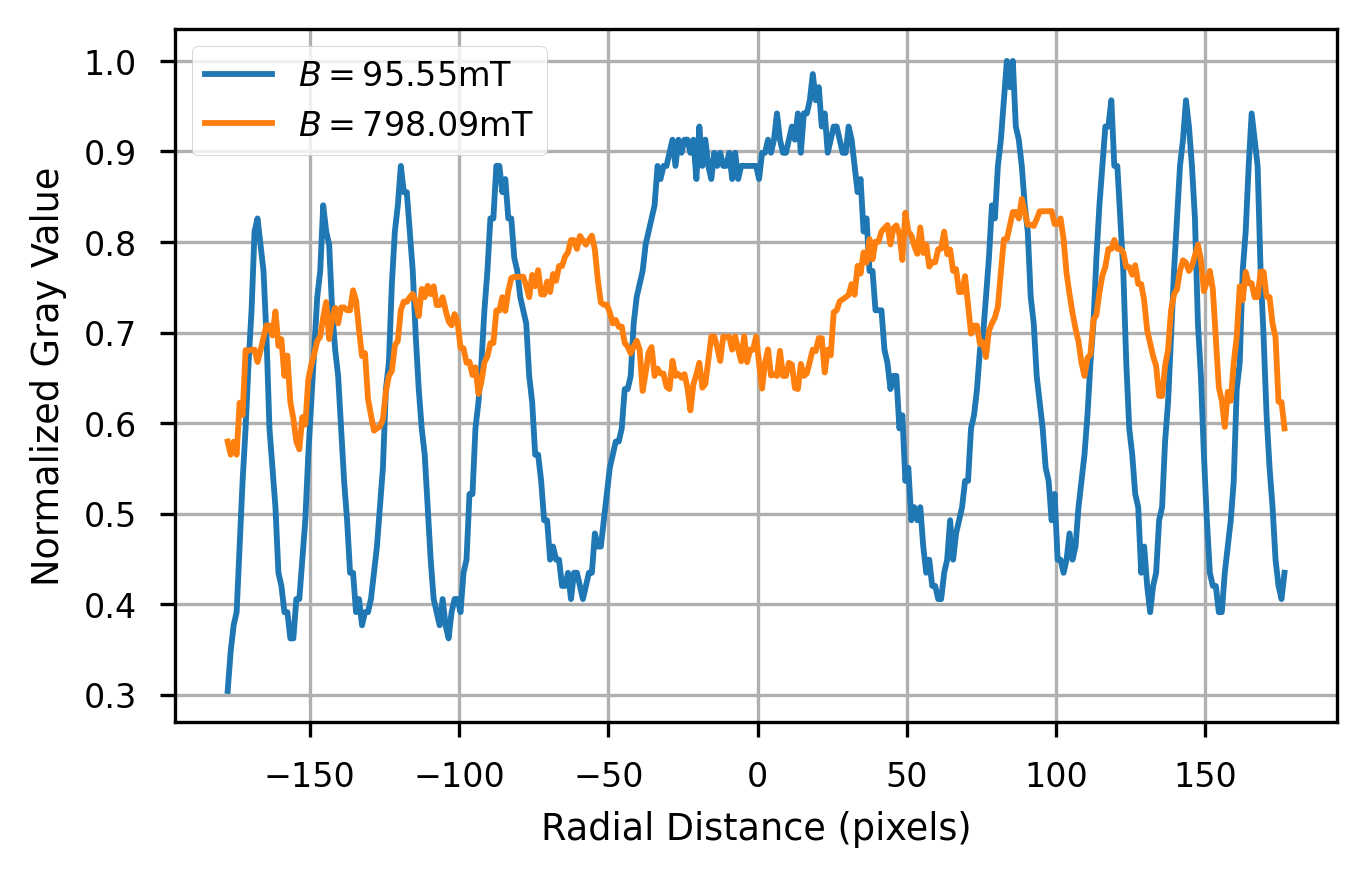

In [6]:
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.style as mtlstyle

from scipy.optimize import curve_fit

mtlstyle.use("seaborn-v0_8-paper")

rcParams["figure.dpi"] = 300
rcParams["figure.figsize"] = (5, 3)

x = pd.read_csv("annormal_0A.csv")
y = pd.read_csv("annormal_10A.csv")

max_v = np.max([x["Gray_Value"].max(), y["Gray_Value"].max()])

plt.plot(x["Distance_(pixels)"] - len(x["Distance_(pixels)"]) / 2, x["Gray_Value"]/max_v, label="$B = 95.55$mT") #Distance_(pixels),Gray_Value
plt.plot(y["Distance_(pixels)"] - len(y["Distance_(pixels)"]) / 2, y["Gray_Value"]/max_v, label="$B = 798.09$mT")
plt.xlabel("Radial Distance (pixels)")
plt.ylabel("Normalized Gray Value")
plt.grid()
plt.legend()